ГЕНЕРАЦИЯ ДАТАСЕТА (ДЛЯ ПРОВЕРКИ РАБОТОСПОСОБНОСТИ)

,date,sales
0,2022-01-01,172.56
1,2022-01-02,188.88
2,2022-01-03,176.65
3,2022-01-04,168.62
4,2022-01-05,158.95
...,...,...
1495,2026-02-04,318.75
1496,2026-02-05,311.37
1497,2026-02-06,320.77
1498,2026-02-07,360.45


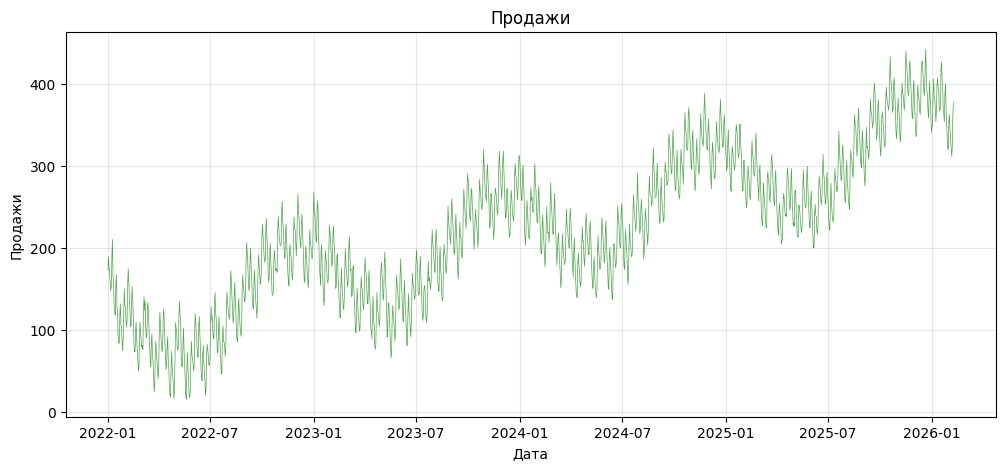

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('sales_data (1).csv', parse_dates=['date'])
display(df)

plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["sales"], linewidth=0.5, alpha=0.7, color='green')
plt.title("Продажи")
plt.xlabel("Дата")
plt.ylabel("Продажи")
plt.grid(True, alpha=0.3)
plt.show()

ПРЕДОБРАБОТКА ДЛЯ ЛИНЕЙНОЙ РЕГРЕССИИ 

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

def add_lags(df, lag_days=[1, 7, 14, 30]):
    df = df.copy()
    for lag in lag_days:
        df[f'sales_lag_{lag}'] = df['sales'].shift(lag)
    df = df.dropna()
    return df

def preprocess_for_lr(df, scaler=None, is_train=True):
    df = df.copy()
    
    # Обработка дат
    df['day_of_week'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['day_of_year'] = df['date'].dt.dayofyear
    df['weekend'] = (df['date'].dt.dayofweek >= 5).astype(int)
    
    # Признаки для модели (лаги + сезонность)
    features = ['sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_30', 
                'day_of_week', 'month', 'weekend']
    
    # Целевая переменная
    target = 'sales'
    
    # Масштабирование
    X = df[features].values
    
    if is_train:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
    else:
        X_scaled = scaler.transform(X)
    
    y = df[target].values

    return X_scaled, y, scaler, df

# Загрузка данных
df = pd.read_csv('sales_data.csv', parse_dates=['date'])

# Добавляем лаги (до разделения)
df = add_lags(df, lag_days=[1, 7, 14, 30])

# Разделение на train/test (80/20)
split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx].copy()
test = df.iloc[split_idx:].copy()

# Предобработка
X_train, y_train, scaler, train_prep = preprocess_for_lr(train, is_train=True)
X_test, y_test, _, test_prep = preprocess_for_lr(test, scaler=scaler, is_train=False)

ЛИНЕЙНАЯ РЕГРЕССИЯ

Линейная регрессия:
    R² на обучающей: 0.9906
    R² на тестовой:  0.8861
    MAE:             7.77


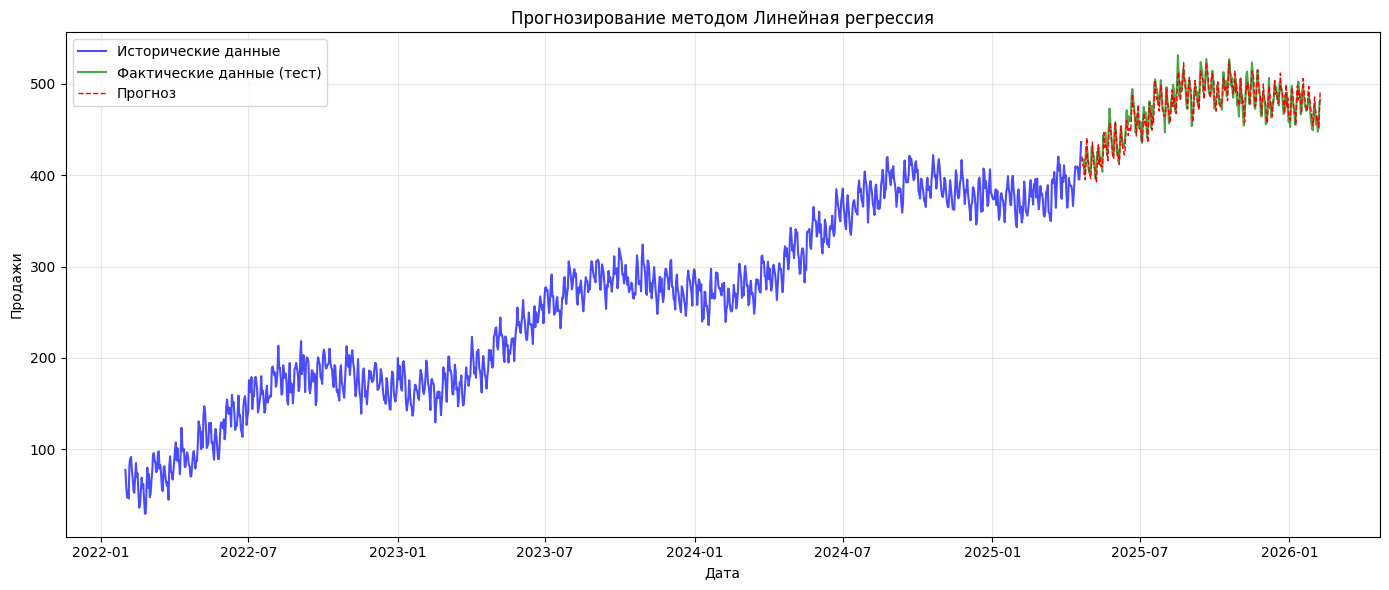

In [3]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

def linear_regression(X_train, y_train, X_test, y_test, train_prep, test_prep):
    # Обучение
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Прогнозы
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Метрики
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    mae = mean_absolute_error(y_test, y_test_pred)
    
    # Вывод
    print("Линейная регрессия:")
    print(f"    R² на обучающей: {r2_train:.4f}")
    print(f"    R² на тестовой:  {r2_test:.4f}")
    print(f"    MAE:             {mae:.2f}")
    
    # График
    plt.figure(figsize=(14, 6))
    
    train_dates = train_prep['date'].values
    test_dates = test_prep['date'].values
    
    plt.plot(train_dates, y_train, label="Исторические данные", color="blue", alpha=0.7)
    plt.plot(test_dates, y_test, label="Фактические данные (тест)", color="green", alpha=0.7)
    plt.plot(test_dates, y_test_pred, label="Прогноз", color="red", linestyle="--", linewidth=1)
    
    plt.title("Прогнозирование методом Линейная регрессия")
    plt.xlabel("Дата")
    plt.ylabel("Продажи")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return model, y_test_pred, {"r2_train": r2_train, "r2_test": r2_test, "mae": mae}

# Запуск
model, predictions, metrics = linear_regression(X_train, y_train, X_test, y_test, train_prep, test_prep)

ПРЕДСКАЗАНИЕ НА БУДУЩЕЕ (БЕЗ ИЗВЕСТНЫХ ЗАРАНЕЕ ДАННЫХ ДЛЯ ПРОВЕРКИ)

Метрики на обучающей выборке: 
    R² :   0.9710
    MAE:  12.45
    RMSE: 15.35
    MAPE: 7.25%

Важность признаков:
    sales_lag_30: 82.308
    sales_lag_7: 31.874
    sales_lag_60: -20.027
    weekend: 16.686
    day_of_week: 8.913
    sales_lag_14: -7.804
    month: 7.516



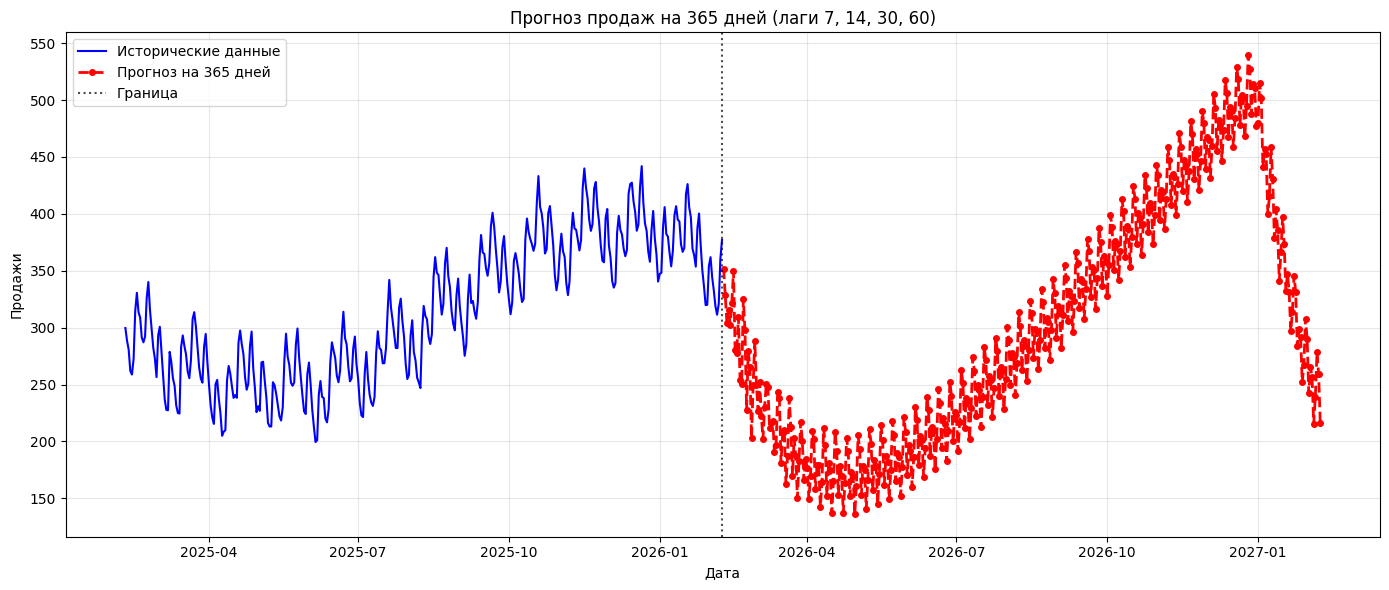


Прогноз на 365 дней:
        date  forecast
0 2026-02-09    351.70
1 2026-02-10    328.34
2 2026-02-11    304.16
3 2026-02-12    315.42
4 2026-02-13    302.68
5 2026-02-14    321.69
6 2026-02-15    349.91
7 2026-02-16    280.21
8 2026-02-17    278.13
9 2026-02-18    309.50
...
          date  forecast
355 2027-01-30    308.02
356 2027-01-31    290.19
357 2027-02-01    242.40
358 2027-02-02    265.50
359 2027-02-03    256.40
360 2027-02-04    215.70
361 2027-02-05    238.93
362 2027-02-06    278.28
363 2027-02-07    259.18
364 2027-02-08    216.20


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

def add_lags(df, lag_days=[7, 14, 30, 60]):
    df = df.copy()
    for lag in lag_days:
        df[f'sales_lag_{lag}'] = df['sales'].shift(lag)
    df = df.dropna()
    return df

def preprocess_for_lr(df, scaler=None):
    df = df.copy()
    
    df['day_of_week'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['weekend'] = (df['date'].dt.dayofweek >= 5).astype(int)
    
    features = ['sales_lag_7', 'sales_lag_14', 'sales_lag_30', 'sales_lag_60', 
                'day_of_week', 'month', 'weekend']
    
    X = df[features].values
    
    if scaler is None:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
    else:
        X_scaled = scaler.transform(X)
    
    return X_scaled, df['sales'].values, scaler

FORECAST_DAYS = 365
HISTORY_DAYS = FORECAST_DAYS

# Загрузка и подготовка
df = pd.read_csv('sales_data (1).csv', parse_dates=['date'])
df_with_lags = add_lags(df, lag_days=[7, 14, 30, 60])

# Обучение на всех данных
X_all, y_all, scaler = preprocess_for_lr(df_with_lags)

# Обучение модели
model = LinearRegression()
model.fit(X_all, y_all)

# Метрики
y_all_pred = model.predict(X_all)

r2 = r2_score(y_all, y_all_pred)
mae = mean_absolute_error(y_all, y_all_pred)
rmse = np.sqrt(mean_squared_error(y_all, y_all_pred))
mape = np.mean(np.abs((y_all - y_all_pred) / y_all)) * 100

print("Метрики на обучающей выборке: ")
print(f"    R² :   {r2:.4f}")
print(f"    MAE:  {mae:.2f}")
print(f"    RMSE: {rmse:.2f}")
print(f"    MAPE: {mape:.2f}%")
print()

# Коэффициенты модели
print("Важность признаков:")
features = ['sales_lag_7', 'sales_lag_14', 'sales_lag_30', 'sales_lag_60', 
            'day_of_week', 'month', 'weekend']
for feat, coef in sorted(zip(features, model.coef_), key=lambda x: abs(x[1]), reverse=True):
    print(f"    {feat}: {coef:.3f}")
print()

# Прогноз на будущее
last_date = df['date'].iloc[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=FORECAST_DAYS, freq='D')

# Берем последние доступные лаги из данных
current_lags = {
    7: df['sales'].iloc[-7],
    14: df['sales'].iloc[-14],
    30: df['sales'].iloc[-30],
    60: df['sales'].iloc[-60]
}

# Прогнозируем последовательно
future_predictions = []
history_for_lags = df['sales'].values.tolist()  # для хранения истории

for i, future_date in enumerate(future_dates):
    row = {
        'sales_lag_7': current_lags[7],
        'sales_lag_14': current_lags[14],
        'sales_lag_30': current_lags[30],
        'sales_lag_60': current_lags[60],
        'day_of_week': future_date.dayofweek,
        'month': future_date.month,
        'weekend': 1 if future_date.dayofweek >= 5 else 0
    }
    
    features_array = np.array([[
        row['sales_lag_7'],
        row['sales_lag_14'],
        row['sales_lag_30'],
        row['sales_lag_60'],
        row['day_of_week'], 
        row['month'], 
        row['weekend']
    ]])
    features_scaled = scaler.transform(features_array)
    
    pred = model.predict(features_scaled)[0]
    future_predictions.append(pred)
    
    # Обновляем историю и лаги для следующего шага
    history_for_lags.append(pred)
    
    current_lags = {
        7: pred,
        14: current_lags[7],
        30: current_lags[14],
        60: current_lags[30]
    }

plt.figure(figsize=(14, 6))

history_df = df.iloc[-HISTORY_DAYS:]

plt.plot(history_df['date'], history_df['sales'], label="Исторические данные", 
         color="blue", linewidth=1.5)
plt.plot(future_dates, future_predictions, label=f"Прогноз на {FORECAST_DAYS} дней", 
         color="red", linestyle="--", linewidth=2, marker="o", markersize=4)

plt.axvline(x=df['date'].iloc[-1], color='black', linestyle=':', alpha=0.7, label='Граница')

plt.title(f"Прогноз продаж на {FORECAST_DAYS} дней (лаги 7, 14, 30, 60)")
plt.xlabel("Дата")
plt.ylabel("Продажи")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

forecast_df = pd.DataFrame({
    'date': future_dates,
    'forecast': [round(x, 2) for x in future_predictions]
})

print(f"\nПрогноз на {FORECAST_DAYS} дней:")
print(forecast_df.head(10))
print("...")
print(forecast_df.tail(10))

forecast_df.to_csv('future_forecast.csv', index=False)

Метрики на обучающей выборке: 
    R² :   0.8324
    MAE:  32.61



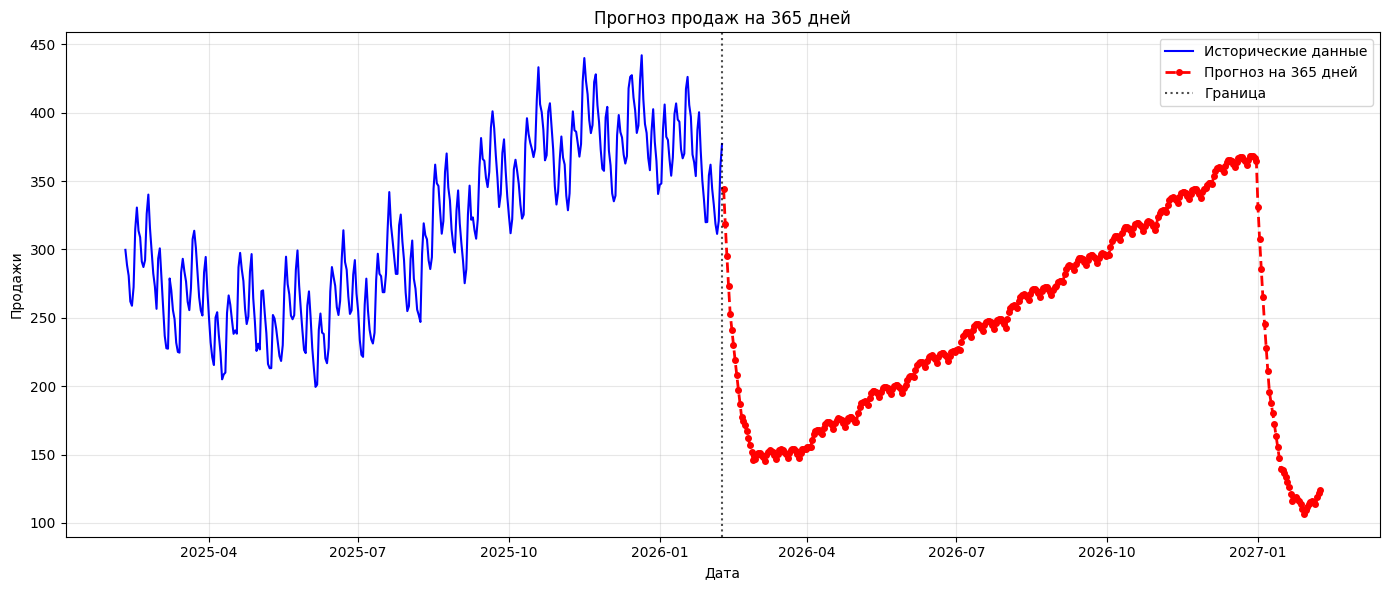


Прогноз на 365 дней:
        date  forecast
0 2026-02-09    344.27
1 2026-02-10    318.52
2 2026-02-11    294.85
3 2026-02-12    273.03
4 2026-02-13    252.82
5 2026-02-14    241.30
6 2026-02-15    230.17
7 2026-02-16    218.92
8 2026-02-17    208.03
9 2026-02-18    197.46
...
          date  forecast
355 2027-01-30    109.67
356 2027-01-31    111.32
357 2027-02-01    114.16
358 2027-02-02    115.69
359 2027-02-03    116.07
360 2027-02-04    115.44
361 2027-02-05    113.92
362 2027-02-06    118.86
363 2027-02-07    122.26
364 2027-02-08    123.79


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

def add_lags(df, lag_days=[14]):
    df = df.copy()
    for lag in lag_days:
        df[f'sales_lag_{lag}'] = df['sales'].shift(lag)
    df = df.dropna()
    return df

def preprocess_for_lr(df, scaler=None):
    df = df.copy()
    
    df['day_of_week'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['weekend'] = (df['date'].dt.dayofweek >= 5).astype(int)
    
    features = ['sales_lag_14', 'day_of_week', 'month', 'weekend']
    
    X = df[features].values
    
    if scaler is None:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
    else:
        X_scaled = scaler.transform(X)
    
    return X_scaled, df['sales'].values, scaler

FORECAST_DAYS = 365
HISTORY_DAYS = FORECAST_DAYS

# Загрузка и подготовка
df = pd.read_csv('sales_data (1).csv', parse_dates=['date'])
df_with_lags = add_lags(df, lag_days=[14])

# Обучение на всех данных
X_all, y_all, scaler = preprocess_for_lr(df_with_lags)

# Обучение модели
model = LinearRegression()
model.fit(X_all, y_all)

# Метрики
y_all_pred = model.predict(X_all)

r2 = r2_score(y_all, y_all_pred)
mae = mean_absolute_error(y_all, y_all_pred)
rmse = np.sqrt(mean_squared_error(y_all, y_all_pred))
mape = np.mean(np.abs((y_all - y_all_pred) / y_all)) * 100

print("Метрики на обучающей выборке: ")
print(f"    R² :   {r2:.4f}")
print(f"    MAE:  {mae:.2f}")
print()

# Прогноз на будущее
last_date = df['date'].iloc[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=FORECAST_DAYS, freq='D')

# Берем последние доступные лаги из данных
current_lags = {
    14: df['sales'].iloc[-14]
}

# Прогнозируем последовательно
future_predictions = []

for future_date in future_dates:
    row = {
        'sales_lag_14': current_lags[14],
        'day_of_week': future_date.dayofweek,
        'month': future_date.month,
        'weekend': 1 if future_date.dayofweek >= 5 else 0
    }
    
    features_array = np.array([[
        row['sales_lag_14'], 
        row['day_of_week'], 
        row['month'], 
        row['weekend']
    ]])
    features_scaled = scaler.transform(features_array)
    
    pred = model.predict(features_scaled)[0]
    future_predictions.append(pred)
    
    # Обновляем лаги для следующего шага
    current_lags = {
        14: pred
    }

plt.figure(figsize=(14, 6))

history_df = df.iloc[-HISTORY_DAYS:]

plt.plot(history_df['date'], history_df['sales'], label="Исторические данные", 
         color="blue", linewidth=1.5)
plt.plot(future_dates, future_predictions, label=f"Прогноз на {FORECAST_DAYS} дней", 
         color="red", linestyle="--", linewidth=2, marker="o", markersize=4)

plt.axvline(x=df['date'].iloc[-1], color='black', linestyle=':', alpha=0.7, label='Граница')

plt.title(f"Прогноз продаж на {FORECAST_DAYS} дней")
plt.xlabel("Дата")
plt.ylabel("Продажи")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

forecast_df = pd.DataFrame({
    'date': future_dates,
    'forecast': [round(x, 2) for x in future_predictions]
})

print(f"\nПрогноз на {FORECAST_DAYS} дней:")
print(forecast_df.head(10))
print("...")
print(forecast_df.tail(10))

forecast_df.to_csv('future_forecast.csv', index=False)